# 📘 Tutorial: the visual detection task dataset

**Ye et al. 2023 (cortical spirals) — Python translation**
*~30 min | no Python experience needed | runs offline*

1. the behavioral task (stimuli, responses, outcomes)
2. how the data is organized on disk
3. loading one session and plotting behavior + imaging

**Part 1** is reading, **Part 2** is code.

**You don't need to know Python to follow Part 2.** Every code cell is a few
lines, each line commented, and §3.1 is a one-screen primer on the four Python
ideas that show up. The heavy lifting sits in a collapsed toolbox cell you can
ignore on a first pass.

**How to run (VS Code)**: select the `spirals-py` kernel and run the cells in
order with `Shift+Enter`. No internet needed — if the kernel won't connect
through a VPN, allow localhost traffic or pause it.

---

# Part 1 — Background: the task and the dataset *(read this)*

## 1. The behavioral task

Four mice (jGCaMP8s: `ZYE_0085/88/90/91`) performed a **2AFC visual contrast
detection task** while widefield calcium imaging (35 Hz) recorded the dorsal
cortex — the task design of Burgess et al. 2017 / Steinmetz et al. 2019:

![2AFC task schematic](assets/burgess2017_fig1AB.jpg)

*Task setup (A) and trial structure (B), from Burgess et al. 2017 (CC BY 4.0).
The auditory cues of panel B were removed in the imaging sessions.*


<video src="assets/clip_3trials.mp4" controls loop muted width="640"
       style="max-width:100%">
  <a href="assets/clip_3trials.mp4">clip_3trials.mp4</a> (your viewer cannot
  play the video inline — open the file directly)
</video>

*Three consecutive trials of the task, from the rig's camera. Watch the wheel:
the mouse holds it still, the Gabor appears, and the turn brings it to the
screen center.*


**One trial**:

1. **Quiescence** — hold the wheel still for 0.4–3 s (mean 0.7 s).
2. **Stimulus** — a Gabor patch on the left or right screen, at 100, 50, 25,
   12, 6 or 0 % contrast (0 % on both sides = *catch trial*).
3. **Response** — the wheel moves the stimulus to the screen center (closed
   loop); the response window is 2–5 s.
4. **Outcome** — correct: sucrose water; wrong side or no response: a 0.5 s
   noise beep.

![timeline of one trial](assets/trial_timeline.png)

The quiescence is a randomized extension of the ~0.5 s inter-trial interval:
the stimulus appears only after the wheel has been still — so the wheel is
stationary, and the onset unpredictable, at stimulus time.


**Trial outcomes** (column `label`):

| label | stimulus | response | meaning |
|---|---|---|---|
| `correct` | yes | correct side | hit (rewarded) |
| `incorrect` | yes | wrong side | error |
| `miss` | yes | none | no response |
| `reject` | no (catch) | none | correct rejection |
| `falarmL` / `falarmR` | no (catch) | any | false alarm |

`response`: **-1 = left, +1 = right, 0 = none**; `reactionTime`: onset to
response (s).

≥ 50 %-contrast trials were repeated until correct; only each trial's first
attempt ("non-repeat trial") is analyzed, and only sessions with **> 70 % hit
rate on both sides**. Each day ended with the same stimuli shown **passively**
(no wheel, no reward).


### 1.1 The wider family of 2AFC choice tasks

The task above belongs to a family of rodent **two-alternative forced-choice
(2AFC)** designs that has carried much of the last decade of systems
neuroscience. Each one reduces a decision to a handful of measurable
quantities — stimulus, choice, outcome, reaction time — that can be aligned to
neural activity trial by trial; that alignment is what makes brain-wide
recordings interpretable at all. *(Papers below are <u>underlined links</u>.)*

**1. Visual detection with a steering wheel (Cortex Lab → IBL).** The design
used here comes from the Carandini and Harris labs: a head-fixed mouse turns a
wheel to bring a Gabor patch to the screen center.
[<u>Steinmetz et al. 2019</u>](https://doi.org/10.1038/s41586-019-1787-x)
recorded ~30,000 neurons across 42 regions with Neuropixels and found choice,
action and engagement signals spread over much of the brain rather than
confined to a "decision area". The International Brain Laboratory then
standardized the identical task across 12 laboratories, which produced the
[<u>IBL 2025</u>](https://doi.org/10.1038/s41586-025-09235-0) brain-wide map
(621,733 neurons, 279 regions) and its companion on
[<u>prior expectations</u>](https://doi.org/10.1038/s41586-025-09226-1); a
[<u>2026 re-analysis</u>](https://doi.org/10.1101/2025.07.30.667641) of the
same data orders cells by function instead of by region and finds tuning
largely unbound from anatomical borders.

**2. Delayed response, memory-guided licking (Svoboda lab).** A head-fixed
mouse feels a pole with its whiskers, holds the answer through a delay, then
licks left or right — so sensation, short-term memory and movement are
separated in time.
[<u>Guo et al. 2014</u>](https://doi.org/10.1016/j.neuron.2013.10.020)
introduced the task and used optogenetics to time when each cortical area is
needed; [<u>Li et al. 2015</u>](https://doi.org/10.1038/nature14178) showed
that anterior lateral motor cortex (ALM) carries a selective preparatory
signal predicting the upcoming lick; and
[<u>Chen et al. 2024</u>](https://doi.org/10.1016/j.cell.2023.12.035)
took it brain-wide with multiple Neuropixels probes, finding choice coding
concentrated in ALM and its subcortical loops.

**3. Evidence accumulation — the Poisson clicks task (Brody lab).** A rat
hears randomly timed click trains in both ears and orients to the side with
more clicks; because every click is timestamped, the experimenter knows
exactly what evidence arrived and when.
[<u>Brunton et al. 2013</u>](https://doi.org/10.1126/science.1233912) used
this to show that rats (and humans) accumulate evidence near-optimally, with
almost no memory leak;
[<u>Duan et al. 2015</u>](https://doi.org/10.1016/j.neuron.2015.05.042) asked
which prefrontal and midbrain regions are actually required. Two recent
Neuropixels studies pin down the *end* of the process:
[<u>Luo et al. 2025</u>](https://doi.org/10.1038/s41586-025-09528-4) caught
**decision commitment** as an abrupt transition in dynamical regime and neural
mode in frontal cortex and striatum, while
[<u>Bondy et al. 2026</u>](https://doi.org/10.1101/2024.08.21.609044)
(preprint) recorded up to 20 regions at once and found the evolving decision
co-fluctuating along a single shared dimension brain-wide, switching state
together at commitment.

**Future directions — cognitive tasks.** Detection is deliberately simple:
one stimulus, one report. The next generation of tasks keeps the same
trial-by-trial rigor but asks for structure, flexibility and inference:

- **one-shot / structure learning** — mice that have learned an abstract task
  structure solve a *new* goal sequence on its first trial, and frontal
  neurons tile "progress to goal" the way place cells tile space
  ([<u>El-Gaby et al. 2024</u>](https://doi.org/10.1038/s41586-024-08145-x));
- **flexible control and subspaces** — macaque frontal cortex holds the items
  of a sequence in separate, generalizable low-dimensional subspaces that can
  be read out forward or backward on command
  ([<u>Chen et al. 2024</u>](https://doi.org/10.1016/j.neuron.2024.07.024),
  Wang lab);
- **hidden internal states** — even in plain 2AFC behavior, a hidden Markov
  model (GLM-HMM) shows mice switching between a discrete "engaged" strategy
  and biased ones, each lasting tens to hundreds of trials
  ([<u>Ashwood et al. 2022</u>](https://doi.org/10.1038/s41593-021-01007-z)).

That last point bears directly on this dataset: the **> 70 % hit-rate session
filter** used above (§1) is a blunt instrument for keeping the mouse in its
engaged state.

## 2. How the data is organized

Everything lives under `task/`: **raw** session folders (from the experiment)
and **derived** tables (built by `pipeline6_task.ipynb`).

![raw vs derived data](assets/data_flow.png)

```
DATA_ROOT/task/
├── sessions/         one Excel table per mouse: sessions + hit rates
├── task_svd/         one folder per session (raw): SVD movie, block events,
│                     photodiode, wheel, mean image
├── task_outcome/     derived behavior tables (one per mouse)
├── task_mean_maps/   across-session average response maps
└── trial_trace/      derived 6-pixel dF/F traces per trial
```

The movie is stored **SVD-compressed**: `frame(t) ≈ U @ V[:, t]` (normalized
by the mean image) — 100 components instead of 560 x 560 numbers per frame.


**The session table** `sessions/<MOUSE>.xlsx` — one row per recorded session:
`date` + `folder` (they name the session folder), `label`
(`task` / `passive` / `rf`), trial counts, and hit rates (`hit_all`,
`hit_left`, `hit_right`).

**The behavior table** `task_outcome/<MOUSE>_task_trial_ID.mat` — one row per
non-repeat trial of all the mouse's sessions: `left_contrast` /
`right_contrast`, `response`, `feedback`, `label`, `reactionTime`, plus
`session` and `trial` numbers to slice out one session.

**The trial traces** `trial_trace/<MOUSE>_task.mat` — dF/F at 6 cortical
pixels, -4 to +4 s around onset, every trial.

(The `.mat` tables are MATLAB v7.3 format; `load_task_table` decodes them
into pandas DataFrames.)


---

# Part 2 — Hands-on: one example session *(run this)*

Each cell does one small thing — run them in order. Our example: **session 5
of ZYE_0085** (2024-07-23), a high-performance session with clear rotating
waves (picked with the paper's spiral detector; the paper's own example figure
uses ZYE_0091). Change `MOUSE` / `SESSION` in the setup cell to explore.


## 3. Setup

Import the packages and point to the data root (`D:\data` by default; override
with the `SPIRALS_DATA_ROOT` environment variable).

In [1]:
import matplotlib.pyplot as plt      # plotting
import numpy as np                   # arrays and math
import pandas as pd                  # tables (like Excel in Python)

from spirals_py.utils.paths import data_root

# a Path is a file location; "/" joins folder names onto it, on any OS
DATA_FOLDER = data_root()  # data release root (set SPIRALS_DATA_ROOT to override)
print("data folder:", DATA_FOLDER, "| exists:", DATA_FOLDER.exists())

MOUSE = "ZYE_0085"  # one of ZYE_0085, ZYE_0088, ZYE_0090, ZYE_0091
SESSION = 5         # 1-based index into the filtered session table
                    # (ZYE_0085 session 5 = 2024-07-23: high performance and
                    #  clear rotating waves in the session-mean response, found
                    #  by scoring all sessions with the spiral detector)

data folder: D:\data | exists: True


### 3.1 A 60-second Python primer

Four ideas cover almost every line in Part 2:

| idea | looks like | means |
|---|---|---|
| **table** (pandas `DataFrame`) | `T.hit_left` | the `hit_left` column of table `T` |
| **boolean mask** | `T.hit_left > 0.7` | a column of `True`/`False`, one per row |
| **filtering** | `T[T.hit_left > 0.7]` | keep only the rows where the mask is `True` |
| **array** (NumPy) | `V[:50, :]` | the first 50 rows of a grid of numbers, all columns |

Two things that trip people up:

- Combine masks with **`&`** (and) and **`|`** (or), *not* the words `and` /
  `or`, and parenthesize each side: `(a > 0) & (b < 1)`.
- A function can return several values at once:
  `U, V, t = load(...)` names them in order. An underscore `_` means
  "returned, but we don't need it".

Counting starts at **0**: `rows.iloc[0]` is the first row. That's why the
session number below gets a `- 1`.

### 3.2 The toolbox (collapsed — click to expand)

Everything below talks to the data through a few functions; the file and
plotting details live inside them. You can treat these as black boxes today —
each one is a single call in the cells that follow:

| function | gives you |
|---|---|
| `load_session(folder)` | the SVD movie (U, V, t), mean image, onset times, wheel velocity |
| `pixel_trace(...)` | full-session dF/F at one atlas pixel |
| `warp_session(...)` | the movie warped to atlas space (`Ut`, `dV`) |
| `average_movie(...)` | trial-averaged response movie of the selected trials |
| `show_epoch` / `show_map` / `show_frames` / `show_video` | the plots |

In [2]:
from spirals_py.task.plots._task_helpers import (
    computeVelocity2,
    correctCounterDiscont,
    imwarp,
    load_h5_var,
    load_tform,
    loadUVt2_h5,
    tsToT,
)
from spirals_py.task.plots._task_helpers_s15 import getPhotodiodeTime, load_block
from spirals_py.task.preprocessing._task_utils import getPhotodiodeTime2
from spirals_py.task.preprocessing.trace_filt_nan import trace_filt_nan
from spirals_py.task.plots.plotCorrectMapsFlow import (
    _colorcet_c06,
    _get_cortex_atlas_path,
    _load_atlas1,
    _load_task_mask,
    _parula,
)
from spirals_py.utils.atlas import plotOutline


# ---- loading: one session folder -> everything in it ------------------------------
def load_session(session_root, passive=False):
    """Load one recording session.

    Returns the SVD-compressed movie (U, V, t, mimg), the stimulus-onset time
    of every (non-repeat) trial from the photodiode signal, the wheel velocity
    interpolated to the imaging times, and the rig's trial-event log (block).
    """
    U, V, t, mimg = loadUVt2_h5(session_root)
    block = load_block(session_root)
    if passive:   # passive sessions have no repeated trials
        stim_times = getPhotodiodeTime2(session_root, block, [0, 5000])
    else:         # keep only each trial's first attempt (non-repeat trials)
        n = np.size(block.events.endTrialValues)
        first = np.asarray(block.events.repeatNumValues).ravel()[:n] == 1
        stim_times = getPhotodiodeTime(session_root, [0, 5000])[:n][first]
    wh = load_h5_var(session_root / "rotaryEncoder_raw.mat", "pd").ravel()
    wheel_t = tsToT(load_h5_var(session_root / "rotaryEncoder_timestamps_Timeline.mat",
                                "tlTimes"), wh.size)
    wheel_vel = computeVelocity2(correctCounterDiscont(wh), 0.01,
                                 1 / np.mean(np.diff(wheel_t)))
    wheel_vel_im = np.interp(t, wheel_t, wheel_vel)
    return U, V, t, mimg, stim_times, wheel_vel_im, block


# ---- atlas transformation -----------------------------------------------------------
def pixel_trace(U, V, mimg, fname, row, col):
    """Full-session dF/F (%) at one atlas pixel."""
    tform = load_tform(DATA_FOLDER / "task" / "rfmap" / f"{fname}.mat")
    Ut = imwarp(U[:, :, :50], tform, (1320, 1140))[::16, ::16, :]
    mimgt = imwarp(mimg, tform, (1320, 1140))[::16, ::16]
    r, c = int(round(row / 16)) - 1, int(round(col / 16)) - 1
    return Ut[r, c, :] @ V[:50, :].astype(float) / mimgt[r, c] * 100


def warp_session(U, V, mimg, fname):
    """Warp a session's SVD components to atlas space and normalize them.

    Returns (Ut, dV): the first 50 spatial components warped to atlas space
    (4x downscaled, normalized by the mean image) and the temporal derivative
    of V.  frame(t) = Ut @ dV[:, t] is then the dV response of that frame.
    """
    tform = load_tform(DATA_FOLDER / "task" / "rfmap" / f"{fname}.mat")
    mimgt = imwarp(mimg, tform, (1320, 1140))[::4, ::4]
    Ut = imwarp(U[:, :, :50], tform, (1320, 1140))[::4, ::4, :]
    with np.errstate(invalid="ignore", divide="ignore"):
        # the mean image is 0 outside the brain -> 0/0 there; harmless, so
        # don't let NumPy print a warning about it
        Ut = Ut / mimgt[:, :, np.newaxis]
    dV = np.concatenate(  # temporal derivative of V (with a leading zero)
        [np.zeros((50, 1)), np.diff(V[:50, :].astype(float), axis=1)], axis=1)
    return Ut, dV


# ---- the recipe: (trial types + onset times) -> average response movie --------------
def average_movie(Ut, dV, t, onset_times, select):
    """Trial-averaged response movie around stimulus onset (-2 to +2 s, 35 Hz).

    onset_times: stimulus onset (photodiode time, s) of every trial;
    select: boolean mask over trials - the trial type to average.
    Returns (movie, n_used); movie has shape (330, 285, 141).
    """
    frames = np.arange(-70, 71)                     # -2..+2 s at 35 Hz
    onset_frame = np.searchsorted(t, onset_times[select])
    acc, n = None, 0
    for f0 in onset_frame:
        f = f0 + frames
        if f[0] < 0 or f[-1] >= dV.shape[1]:
            continue                                # onset too close to an edge
        movie = Ut.reshape(-1, 50) @ dV[:, f]
        acc = movie if acc is None else acc + movie
        n += 1
    return acc.reshape(330, 285, 141) / n, n


t_map = np.arange(-70, 71) / 35                     # time axis of the movies

# ---- plotting (paper's Fig. 5b style: cortex mask + atlas outlines) ------------------
parula = _parula()
c06 = _colorcet_c06()
BW2 = _load_task_mask(DATA_FOLDER, 4)      # cortex mask, 330 x 285
atlas1 = _load_atlas1(DATA_FOLDER)         # atlas area labels
maskPath, st = _get_cortex_atlas_path(DATA_FOLDER)


def show_map(ax, data, cmap, vmin, vmax):
    """imshow with the cortex mask as alpha + atlas outlines (Fig. 5b style)."""
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, alpha=BW2)
    plotOutline(maskPath[0:11], st, atlas1, None, 5 / 4, "k", ax=ax)
    ax.set_aspect("equal")
    ax.axis("off")
    return im


def show_epoch(t, trace, wheel_vel, stim_times, trials, t0, t1, title="", label=""):
    """A chunk of the session (t0..t1 s) on one time axis: the widefield trace,
    the wheel velocity, and every trial's stimulus (bar height = signed
    contrast, color = outcome) with its response (x marker)."""
    outcome_color = {"correct": "tab:green", "incorrect": "tab:orange", "miss": "tab:red",
                     "reject": "tab:gray", "falarmL": "tab:purple", "falarmR": "tab:purple"}

    fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

    # top: the widefield trace
    axes[0].plot(t, trace, lw=0.8, color="tab:blue")
    if label:
        axes[0].text(0.99, 0.95, label, transform=axes[0].transAxes,
                     ha="right", va="top", fontsize=9)
    axes[0].set_ylabel("dF/F (%)")
    axes[0].set_title(title)

    # middle: wheel velocity
    axes[1].plot(t, wheel_vel, lw=0.8, color="tab:blue")
    axes[1].set_ylabel("wheel velocity")

    # bottom: every trial in the chunk
    for i in range(len(trials)):
        onset = stim_times[i]
        if not (t0 <= onset <= t1):
            continue
        signed_contrast = trials.right_contrast.iloc[i] - trials.left_contrast.iloc[i]
        color = outcome_color[trials.label.iloc[i]]
        axes[2].plot([onset, onset], [0, signed_contrast], color=color, lw=2)
        axes[2].plot(onset, signed_contrast, "o", color=color, ms=5)
        if trials.response.iloc[i] != 0:
            axes[2].plot(onset + trials.reactionTime.iloc[i], 0, "x", color=color, ms=7)
    axes[2].axhline(0, color="k", lw=0.5)
    axes[2].set_ylabel("signed contrast")
    axes[2].set_xlabel("time in session (s)")

    # dashed lines at every stimulus onset, in all panels
    for ax in axes:
        for i in range(len(trials)):
            if t0 <= stim_times[i] <= t1:
                ax.axvline(stim_times[i], color="k", ls="--", lw=0.5, alpha=0.5)
        ax.set_xlim(t0, t1)

    plt.show()


def show_frames(movie, phase, frames, tt):
    """Frames of a response movie: raw (top, parula) and 2-8 Hz phase
    (bottom, C06) - the layout of the paper's Fig. 5b, cortex-masked."""
    vmax = np.nanpercentile(np.abs(movie[:, :, frames]), 99.9)
    fig, axes = plt.subplots(2, len(frames), figsize=(16, 3.4))
    for c, f in enumerate(frames):
        show_map(axes[0, c], movie[:, :, f], parula, -vmax, vmax)
        show_map(axes[1, c], phase[:, :, f], c06, -np.pi, np.pi)
        axes[0, c].set_title(f"{tt[f]:+.2f}")
    axes[0, 0].set_ylabel("raw", fontsize=11)
    axes[1, 0].set_ylabel("phase", fontsize=11)
    plt.show()


def show_video(movie, phase, frames, tt):
    """The same two views as an animation (HTML player, 35 Hz)."""
    from matplotlib.animation import FuncAnimation
    from IPython.display import HTML

    vmax = np.nanpercentile(np.abs(movie[:, :, frames]), 99.9)
    fig, axes = plt.subplots(1, 2, figsize=(8, 3.8), dpi=60)
    im_raw = show_map(axes[0], movie[:, :, frames[0]], parula, -vmax, vmax)
    im_ph = show_map(axes[1], phase[:, :, frames[0]], c06, -np.pi, np.pi)
    axes[0].set_title("average response (dV)")
    axes[1].set_title("2-8 Hz phase")
    title = fig.suptitle("")

    def update(f):
        im_raw.set_data(movie[:, :, f])
        im_ph.set_data(phase[:, :, f])
        title.set_text(f"t = {tt[f]:+.2f} s")
        return [im_raw, im_ph]

    anim = FuncAnimation(fig, update, frames=frames, interval=1000 / 35)
    out = HTML(anim.to_jshtml())
    plt.close(fig)
    return out


## 4. Behavior of the example session

First the session table of this mouse, then the trials of one session. Both
are pandas tables, and both get narrowed down with a boolean mask (§3.1).

In [3]:
# read the session table (one row per recorded session)
T_session = pd.read_excel(DATA_FOLDER / "task" / "sessions" / f"{MOUSE}.xlsx")

# keep only the sessions used in the analysis:
# label == "task" and hit rate above 70% on both sides.
# each of these three is a column of True/False, one entry per session:
is_task = T_session.label == "task"
good_left = T_session.hit_left > 0.7
good_right = T_session.hit_right > 0.7

# "&" combines them row by row (True only where all three are True);
# reset_index renumbers the surviving rows 0, 1, 2, ...
T1 = T_session[is_task & good_left & good_right].reset_index(drop=True)
print(f"-> {len(T1)} high-performance task sessions")
T1   # the last line of a cell is displayed automatically

-> 10 high-performance task sessions


,MouseID,date,folder,block_folder,label,norepeat,trials,hit_all,hit_left,hit_right
0,ZYE_0085,2024-07-11,1,2,task,489.0,612.0,0.877246,0.872483,0.881081
1,ZYE_0085,2024-07-12,1,2,task,66.0,518.0,0.938776,0.785714,1.000000
2,ZYE_0085,2024-07-13,2,3,task,352.0,508.0,0.878788,0.761905,0.976190
3,ZYE_0085,2024-07-17,1,2,task,385.0,530.0,0.853147,0.719424,0.979592
4,ZYE_0085,2024-07-23,1,2,task,520.0,595.0,0.902208,0.874214,0.930380
5,ZYE_0085,2024-07-24,1,2,task,716.0,774.0,0.957179,0.944162,0.970000
6,ZYE_0085,2024-07-25,1,2,task,136.0,137.0,1.000000,1.000000,1.000000
7,ZYE_0085,2024-07-26,1,2,task,366.0,431.0,0.897059,0.805825,0.990099
8,ZYE_0085,2024-07-27,3,4,task,492.0,524.0,0.935849,0.952756,0.920290
9,ZYE_0085,2024-07-28,1,2,task,473.0,586.0,0.849315,0.728814,0.990099


In [4]:
from spirals_py.task.preprocessing.load_task_table import load_task_table

# one row per non-repeat trial of the mouse, with each trial's session number
trial_all = load_task_table(
    DATA_FOLDER / "task" / "task_outcome" / f"{MOUSE}_task_trial_ID.mat", "trial_all"
)
print(f"{len(trial_all)} trials from {int(trial_all.session.max())} sessions")

# pick out the trials of our example session: keep the rows whose
# "session" column equals SESSION
trials = trial_all[trial_all.session == SESSION].reset_index(drop=True)
print(f"session {SESSION}: {len(trials)} trials")
trials.head(10)   # the first 10 rows

4283 trials from 10 sessions
session 5: 542 trials


,session,trial,left_contrast,right_contrast,response,feedback,miss,correct,incorrect,reject,falarmL,falarmR,label,reactionTime
0,5.0,1.0,0.000,1.000,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,correct,0.408827
1,5.0,2.0,0.500,0.000,-1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,correct,2.164655
2,5.0,3.0,0.000,0.500,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,correct,0.280711
3,5.0,4.0,1.000,0.000,-1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,correct,0.290447
4,5.0,5.0,0.000,0.500,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,correct,0.262000
5,5.0,6.0,0.060,0.000,-1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,correct,0.429654
6,5.0,7.0,0.125,0.000,-1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,correct,0.323512
7,5.0,8.0,0.060,0.000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,incorrect,0.419853
8,5.0,9.0,0.000,0.500,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,correct,0.307241
9,5.0,10.0,0.000,0.125,-1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,incorrect,3.477151


## 5. A whole epoch of the session

When did things happen, and what did the brain do? A **100 s chunk** of the
session on one time axis: a widefield trace, the wheel velocity, and every
trial's stimulus and outcome (a simplified version of the paper's Extended
Data Fig. 14b).

It takes three steps: name the session's folder, load it, pull out one pixel's
trace.

In [5]:
# one row of the table = one session. .iloc[i] picks row number i, counting
# from 0 - so our session 5 is row 4, hence the "- 1".
row = T1.iloc[SESSION - 1]

# the session folder is named <MouseID>_<date>_<folder>, e.g. ZYE_0085_20240723_1
date_text = pd.Timestamp(row.date).strftime("%Y%m%d")   # 2024-07-23 -> "20240723"
fname = f"{row.MouseID}_{date_text}_{int(row.folder)}"
session_root = DATA_FOLDER / "task" / "task_svd" / fname
print("session folder:", session_root)

session folder: D:\data\task\task_svd\ZYE_0085_20240723_1


In [6]:
# everything this session offers, in one call. load_session returns seven
# things; we name them in order, and "_" is the one we don't need here.
U, V, t_im, mimg, stim_times, wheel_vel_im, _ = load_session(session_root)

# this is the SVD compression from Part 1: U holds the spatial patterns and
# V their strength over time, so U @ V rebuilds the full 560 x 560 movie
print(f"U (space): {U.shape}    V (time): {V.shape}")
print(f"{stim_times.size} stimulus onsets in this session")

# one full-session widefield trace, at a right motor-cortex pixel (SSp-ul)
trace_ssp = pixel_trace(U, V, mimg, fname, 512, 850)
print("trace and wheel velocity ready")

U (space): (560, 560, 100)    V (time): (100, 134843)
542 stimulus onsets in this session


trace and wheel velocity ready


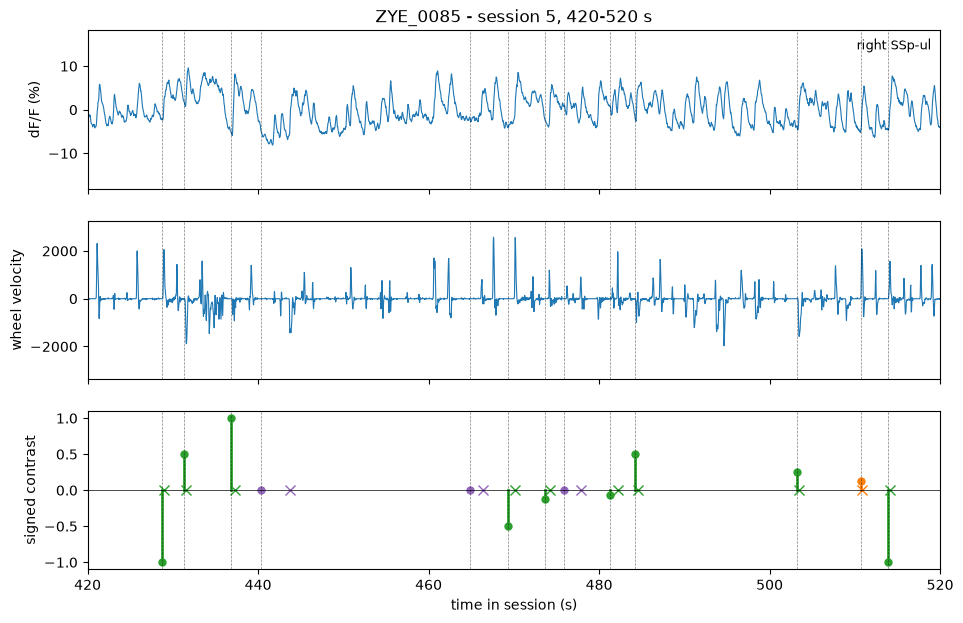

In [7]:
# the epoch plot: 100 s of the session
t0, t1 = 420, 520   # the chunk to show - change these to look elsewhere
show_epoch(t_im, trace_ssp, wheel_vel_im, stim_times, trials, t0, t1,
           title=f"{MOUSE} - session {SESSION}, {t0}-{t1} s", label="right SSp-ul")

## 6. The psychometric curve

The classic summary of the task: hit rate vs. stimulus contrast, separately
for left and right stimuli. First the numbers, then the plot.

In [8]:
# keep only the trials that had a stimulus (drop the 0%-contrast catch trials).
# "|" is or; .copy() gives us our own table to add columns to.
stim = trials[(trials.left_contrast > 0) | (trials.right_contrast > 0)].copy()

# a trial has contrast on one side only, so the larger of the two columns is
# "the" contrast, and np.where picks the side label row by row (an if/else)
stim["contrast"] = np.maximum(stim.left_contrast, stim.right_contrast)
stim["side"] = np.where(stim.right_contrast > 0, "right", "left")

contrast_levels = [0.06, 0.125, 0.25, 0.5, 1.0]

# hit rate = the average of the "correct" column (1 = hit, 0 = no hit)
# among the trials at one contrast on one side
hit_rate = {"left": [], "right": []}
for side in ("left", "right"):
    for c in contrast_levels:
        these = stim[(stim.side == side) & (stim.contrast == c)]
        hit_rate[side].append(these.correct.mean())

pd.DataFrame(hit_rate, index=[f"{c * 100:g}%" for c in contrast_levels])

,left,right
6%,0.633333,0.727273
12.5%,0.848485,0.903226
25%,0.906250,1.000000
50%,0.823529,0.903226
100%,0.864583,0.947917


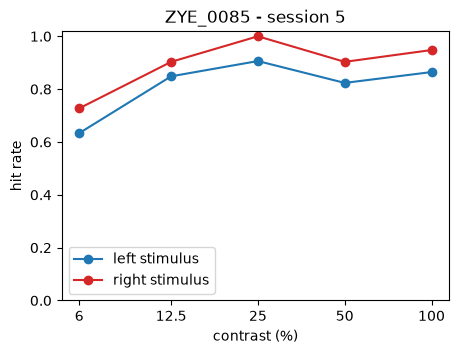

In [9]:
# the same numbers as a curve, on a log contrast axis
fig, ax = plt.subplots(figsize=(5, 3.5))
for side, color in (("left", "tab:blue"), ("right", "tab:red")):
    ax.semilogx(np.array(contrast_levels) * 100, hit_rate[side], "o-",
                color=color, label=f"{side} stimulus")
ax.set_xticks([c * 100 for c in contrast_levels])
ax.set_xticklabels(["6", "12.5", "25", "50", "100"])
ax.minorticks_off()
ax.set(xlabel="contrast (%)", ylabel="hit rate", ylim=(0, 1.02),
       title=f"{MOUSE} - session {SESSION}")
ax.legend()
plt.show()

## 7. Widefield responses

One recipe: pick trials by type, take their onset times, average the response
movie around onset — then plot. With the toolbox, each step is 2–3 lines:

1. the average task response and its rotating waves (the paper's Fig. 5b)
2. the same for passive viewing
3. the passive response at the contralateral V1 pixel


### 7.1 The average response and its rotating waves

Average the selected trials' movies around onset — using **dV** (the temporal
derivative, which removes slow global brightness changes) — then band-pass the
average to **2–8 Hz** and plot the Hilbert **phase**: a rotating wave is a
pinwheel, the phase circling around a center, that turns over frames (the
paper's Fig. 5b).


averaged 83 trials of the example session


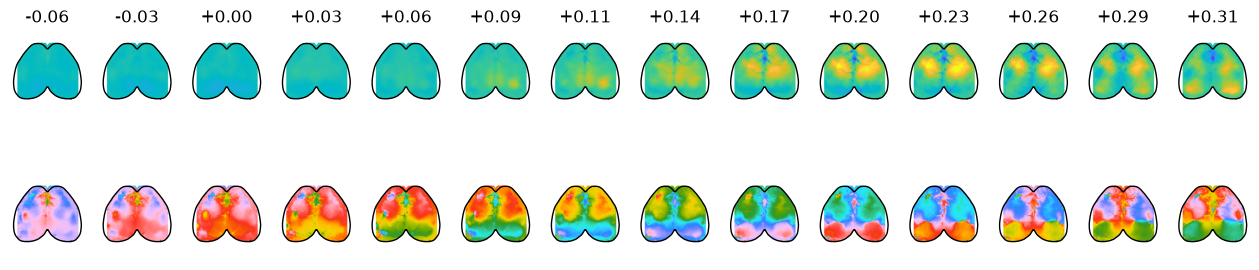

In [10]:
# the average response of the example session (correct, 100%-contrast, left trials)
Ut, dV = warp_session(U, V, mimg, fname)     # warp to atlas space + normalize

# a True/False mask over trials - the ones we want to average.
# .values drops the pandas wrapper and leaves a plain NumPy array.
wanted = ((trials.label == "correct") & (trials.left_contrast == 1)).values
average_task, n_task = average_movie(Ut, dV, t_im, stim_times, wanted)
print(f"averaged {n_task} trials of the example session")

# its 2-8 Hz phase, at the same 14 frames as the paper's Fig. 5b
_, tracePhase = trace_filt_nan(average_task)
fig5b_frames = np.arange(68, 82)   # -0.06 to +0.31 s around onset (frame 70 = onset)
show_frames(average_task, tracePhase, fig5b_frames, t_map)

In [11]:
# the same two views as an animation at full 35 Hz, -0.25 to +0.5 s
# (press play under the figure)
show_video(average_task, tracePhase, np.arange(61, 89), t_map)

### 7.2 The same stimulus, but passive viewing

The same mouse at the end of the day, same stimuli but **passive** (no wheel,
no reward). Without the wheel turn's bilateral motor recruitment, the response
stays confined to the **contralateral** visual cortex.


In [12]:
# the first passive-viewing session of this mouse: filter by label, take row 0
passive_row = T_session[T_session.label == "passive"].iloc[0]
date_text_p = pd.Timestamp(passive_row.date).strftime("%Y%m%d")
fname_p = f"{passive_row.MouseID}_{date_text_p}_{int(passive_row.folder)}"
session_root_p = DATA_FOLDER / "task" / "task_svd" / fname_p
print("passive session:", session_root_p)

# the same loader (passive sessions log their onsets slightly differently)
U_p, V_p, t_p, mimg_p, stim_p, _, block_p = load_session(session_root_p, passive=True)

passive session: D:\data\task\task_svd\ZYE_0085_20240710_3


In [13]:
# which passive trials showed 100% contrast on the left?
# the rig's log stores one value per trial; np.asarray(...).ravel() turns that
# log entry into a flat NumPy array of numbers we can compare.
n_trials_p = np.size(block_p.events.endTrialValues)      # completed trials
left_contrast_p = np.asarray(block_p.events.contrastLeftValues).ravel()[:n_trials_p]
wanted_p = (left_contrast_p == 1)[: stim_p.size]         # True where contrast == 100%
print(f"{wanted_p.sum()} of {wanted_p.size} passive trials at 100% left contrast")

50 of 1000 passive trials at 100% left contrast


In [14]:
# the same recipe as in the task session: warp, select trials, average
Ut_p, dV_p = warp_session(U_p, V_p, mimg_p, fname_p)
average_passive, n_used_p = average_movie(Ut_p, dV_p, t_p, stim_p, wanted_p)
_, tracePhase_p = trace_filt_nan(average_passive)
print(f"averaged {n_used_p} passive trials")

averaged 50 passive trials


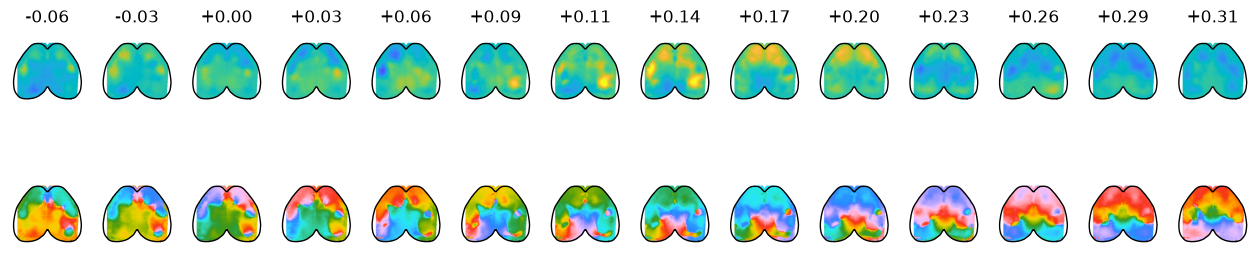

In [15]:
# passive viewing: the same figure (average response + 2-8 Hz phase)
show_frames(average_passive, tracePhase_p, fig5b_frames, t_map)


### 7.3 The response at the contralateral V1 pixel

The simplest summary: the passive mean response at its peak (+0.11 s), with
the **contralateral V1 pixel** marked — and its mean trace.


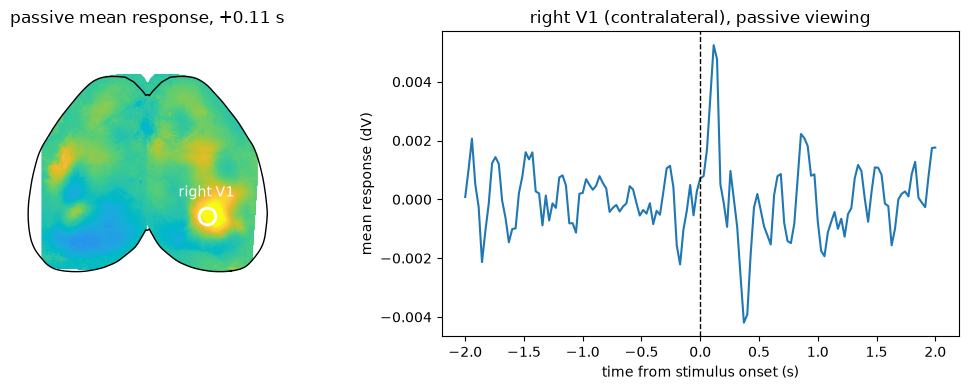

In [16]:
# passive mean response at +0.11 s (frame 74; frame 70 = onset),
# with the right (contralateral) V1 pixel and its mean trace
vmax_pass = np.nanpercentile(np.abs(average_passive[:, :, fig5b_frames]), 99.9)
row, col = 199, 206   # right V1 (contralateral) - atlas (796, 824)

# one figure, two panels side by side: the map and the trace
fig, (ax_map, ax_trace) = plt.subplots(1, 2, figsize=(11, 4))

# left panel: the response map at frame 74, with the pixel circled
show_map(ax_map, average_passive[:, :, 74], parula, -vmax_pass, vmax_pass)
ax_map.set_title("passive mean response, +0.11 s")
ax_map.plot(col, row, "o", ms=12, mfc="none", mec="w", mew=2)
ax_map.annotate("right V1", (col, row), xytext=(0, 14),
                textcoords="offset points", color="w", fontsize=10, ha="center")

# right panel: that one pixel's value across all 141 frames
ax_trace.plot(t_map, average_passive[row, col, :])
ax_trace.axvline(0, color="k", ls="--", lw=1)   # stimulus onset
ax_trace.set(xlabel="time from stimulus onset (s)", ylabel="mean response (dV)",
             title="right V1 (contralateral), passive viewing")
fig.tight_layout()
plt.show()

---

## ✅ Summary

- **Task**: 2AFC contrast detection with a closed-loop wheel report.
- **Behavior** is a tidy table (`trial_all`); `.session` slices out one session.
- **Imaging** is SVD-compressed (`U`, `V`); averaging **dV** around photodiode
  onsets gives response movies for any trial type.
- The 2–8 Hz **phase** of the average shows rotating waves (pinwheels);
  cross-session means live under `task/task_mean_maps/`.
- **Passive viewing** runs through the same pipeline.

**The Python you just used**: reading a table (`pd.read_excel`), filtering it
with a boolean mask (`T[T.hit > 0.7]`), slicing arrays (`V[:50, :]`), a `for`
loop to fill a list, and calling functions that return several values at once.
That is the whole vocabulary.

**Where to go next**: `figure6_task.ipynb` (the paper's figures),
`pipeline6_task.ipynb` (raw → derived), `spirals_py/task/` (the code) — or
change `MOUSE` / `SESSION` and rerun 🎉